In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Cropping2D, GlobalMaxPooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Mengecek direktori saat ini
current_dir = os.getcwd()
print("Direktori awal:", current_dir)

# Jika masih di dalam folder 'notebooks', naik satu tingkat ke folder root proyek
if current_dir.endswith("notebooks"):
    os.chdir("..")
    print("Direktori setelah disesuaikan:", os.getcwd())


Direktori awal: d:\pokemon-tcg-classification\notebooks
Direktori setelah disesuaikan: d:\pokemon-tcg-classification


In [3]:
# ==========================================
# 1. KONFIGURASI PARAMETER & DIREKTORI
# ==========================================
TRAIN_DIR = os.path.join("data", "processed", "train")
VAL_DIR = os.path.join("data", "processed", "val")

# Berdasarkan batasan: Resize 300x420 (width, height)
# Dalam Keras, format target_size adalah (height, width)
IMG_HEIGHT = 420
IMG_WIDTH = 300
BATCH_SIZE = 32
NUM_CLASSES = 10


In [4]:
# ==========================================
# 2. PRA-PEMROSESAN & AUGMENTASI DATA (UPDATE UNTUK ROI)
# ==========================================
print("Menyiapkan Data Generator...")

# Augmentasi geometris (rotasi, zoom, flip) DIHAPUS TOTAL 
# agar letak simbol set tidak tergeser keluar dari jendela Cropping2D model.
# Hanya menggunakan augmentasi pencahayaan.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.8, 1.2] # Variasi pencahayaan yang sedikit diperlebar
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Mengambil semua label kelas dari data latih
train_classes = train_generator.classes

# Menghitung bobot secara otomatis
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)

# Konversi ke dictionary agar bisa dibaca oleh Keras
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights yang akan digunakan:", class_weight_dict)


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.
Class Weights yang akan digunakan: {0: np.float64(1.1145833333333333), 1: np.float64(0.9441176470588235), 2: np.float64(0.9786585365853658), 3: np.float64(1.2067669172932332), 4: np.float64(0.9331395348837209), 5: np.float64(0.823076923076923), 6: np.float64(0.9385964912280702), 7: np.float64(1.284), 8: np.float64(1.0354838709677419), 9: np.float64(0.9119318181818182)}


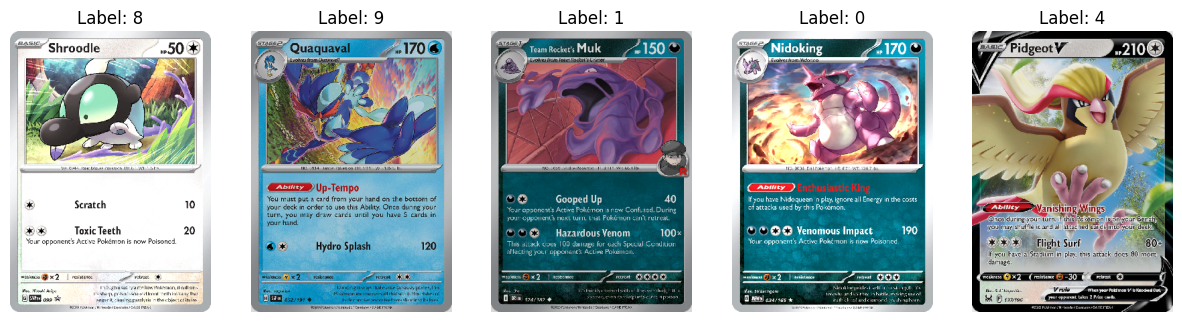

In [5]:
# Mengambil satu batch data latih
x_batch, y_batch = next(train_generator)

# Menampilkan 5 gambar pertama dari batch tersebut
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.title(f"Label: {y_batch[i].argmax()}")
    plt.axis("off")
plt.show()


In [6]:
print("Membangun Arsitektur Internal Region of Interest (RoI)...")

# 1. Definisi Input (Sistem tetap menerima Full Card)
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. INTERNAL CROPPING (Membuang Noise)
# Memotong 55% bagian atas dan 40% bagian kanan gambar
# Menyisakan area kiri bawah yang berisi simbol set
top_crop = int(IMG_HEIGHT * 0.55)
bottom_crop = 0
left_crop = 0
right_crop = int(IMG_WIDTH * 0.40)

x = Cropping2D(cropping=((top_crop, bottom_crop), (left_crop, right_crop)), name='roi_cropping')(inputs)

# 3. Base Model MobileNetV2 (Hanya memproses area yang sudah di-crop)
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(None, None, 3) # Fleksibel terhadap ukuran hasil crop
)
base_model.trainable = False 

x = base_model(x)

# 4. Deteksi Simbol (Tahan terhadap pergeseran koordinat)
x = GlobalMaxPooling2D()(x)

# 5. Classifier Layers
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x) # Kapasitas cukup 128 karena fitur sudah sangat spesifik
x = Dropout(0.4)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)


Membangun Arsitektur Internal Region of Interest (RoI)...


C:\Users\aryay\AppData\Local\Temp\ipykernel_3156\2747273505.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [7]:
print("\n=== Memulai Tahap 1: Feature Extraction (Area Kiri Bawah) ===")
history_phase1 = model.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=class_weight_dict
)



=== Memulai Tahap 1: Feature Extraction (Area Kiri Bawah) ===
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 43s 754ms/step - accuracy: 0.1558 - loss: 5.5629 - val_accuracy: 0.2206 - val_loss: 5.1495
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 704ms/step - accuracy: 0.2492 - loss: 4.6679 - val_accuracy: 0.2794 - val_loss: 4.3004
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 712ms/step - accuracy: 0.3140 - loss: 4.1354 - val_accuracy: 0.3000 - val_loss: 3.8916
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 707ms/step - accuracy: 0.3539 - loss: 3.7403 - val_accuracy: 0.3235 - val_loss: 3.6588
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 716ms/step - accuracy: 0.3857 - loss: 3.4883 - val_accuracy: 0.3588 - val_loss: 3.5017
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 725ms/step - accuracy: 0.4287 - loss: 3.2689 - val_accuracy: 0.3529 - val_loss: 3.3162
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 39s 761ms/step - accuracy: 0.4735 - loss: 3.0265 - val_accuracy: 0.3500 - val_loss: 3.2031
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━

In [8]:
# TAHAP 2: FINE-TUNING
print("\n=== Memulai Tahap 2: Fine-Tuning Terukur ===")
base_model.trainable = True

# Membekukan 75% layer awal MobileNetV2
freeze_until = int(len(base_model.layers) * 0.75)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

history_phase2 = model.fit(
    train_generator,
    epochs=25, 
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)



=== Memulai Tahap 2: Fine-Tuning Terukur ===
Epoch 1/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step - accuracy: 0.2280 - loss: 2.8914 - val_accuracy: 0.2559 - val_loss: 3.1535 - learning_rate: 1.0000e-04
Epoch 2/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 867ms/step - accuracy: 0.4081 - loss: 2.4390 - val_accuracy: 0.2529 - val_loss: 3.0431 - learning_rate: 1.0000e-04
Epoch 3/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 868ms/step - accuracy: 0.5059 - loss: 2.2480 - val_accuracy: 0.2441 - val_loss: 2.9336 - learning_rate: 1.0000e-04
Epoch 4/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 864ms/step - accuracy: 0.5738 - loss: 2.1020 - val_accuracy: 0.2500 - val_loss: 3.0046 - learning_rate: 1.0000e-04
Epoch 5/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 865ms/step - accuracy: 0.6299 - loss: 1.9727 - val_accuracy: 0.2265 - val_loss: 2.9329 - learning_rate: 1.0000e-04
Epoch 6/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 867ms/step - accuracy: 0.6891 - loss: 1.8795 - val_accuracy: 0.2735 - val_loss: 2.7958 - learning_rate: 1.0000e-04
Epoch 7/25
5

In [9]:
# Menyimpan model yang sudah dilatih ke folder models/
model_path = os.path.join('models', 'mobilenetv2_pokemon_tcg.keras')
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")


Model berhasil disimpan di: models\mobilenetv2_pokemon_tcg.keras


In [10]:
# ==========================================
# 4. EVALUASI MODEL PADA DATA UJI (TEST SET)
# ==========================================
TEST_DIR = os.path.join('data', 'processed', 'test')

# Hanya normalisasi, tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # PENTING: Jangan diacak agar y_true dan y_pred sejajar
)

# Menghitung Akurasi dan Loss dasar
print("Mengevaluasi model...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Test Set: {test_acc * 100:.2f}%")
print(f"Loss pada Test Set: {test_loss:.4f}")


Found 355 images belonging to 10 classes.
Mengevaluasi model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 506ms/step - accuracy: 0.5408 - loss: 2.0481

Akurasi pada Test Set: 54.08%
Loss pada Test Set: 2.0481


Melakukan prediksi pada Test Set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 590ms/step

=== Laporan Klasifikasi (Classification Report) ===
                       precision    recall  f1-score   support

                  151       1.00      0.50      0.67        32
      destined-rivals       0.56      0.74      0.64        38
       evolving-skies       0.57      0.83      0.67        36
     journey-together       0.69      0.69      0.69        29
          lost-origin       0.84      0.42      0.56        38
       paldea-evolved       0.57      0.60      0.58        43
        paldean-fates       0.43      0.68      0.53        38
 prismatic-evolutions       0.26      0.29      0.27        28
scarlet-violet-promos       0.47      0.41      0.44        34
       surging-sparks       0.40      0.21      0.27        39

             accuracy                           0.54       355
            macro avg       0.58      0.54      0.53       355
         weighted avg       0.58      0.54      0

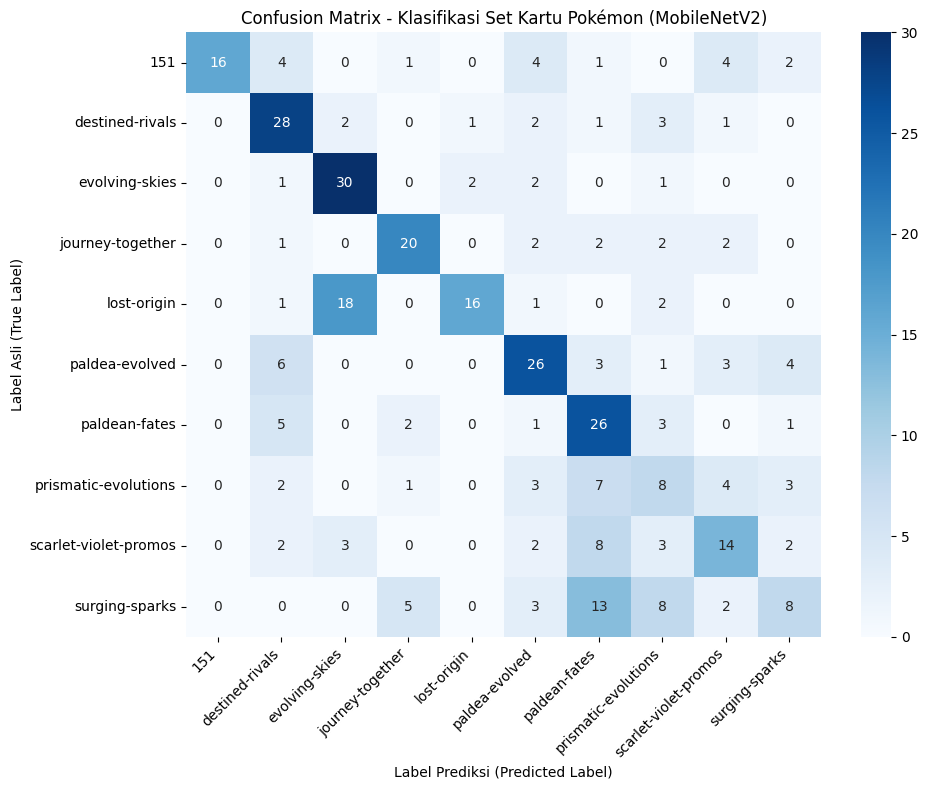

In [11]:
print("Melakukan prediksi pada Test Set...")
# Mendapatkan probabilitas prediksi
predictions = model.predict(test_generator)

# Mengambil indeks kelas dengan probabilitas tertinggi (argmax)
y_pred = np.argmax(predictions, axis=1)

# Mengambil label asli dari generator
y_true = test_generator.classes

# Mengambil nama-nama kelas (10 Set Pokémon)
class_names = list(test_generator.class_indices.keys())

# 1. Classification Report (Precision, Recall, F1-Score)
print("\n=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Set Kartu Pokémon (MobileNetV2)')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Menyimpan gambar Confusion Matrix ke folder reports (opsional tapi disarankan untuk skripsi)
cm_path = os.path.join('reports', 'confusion_matrix_mobilenet.png')
# Pastikan folder reports ada
os.makedirs('reports', exist_ok=True)
plt.savefig(cm_path)
print(f"Confusion Matrix berhasil disimpan di: {cm_path}")

plt.show()


Menghasilkan Learning Curves...
Learning Curves berhasil disimpan di: reports\learning_curves_mobilenet.png


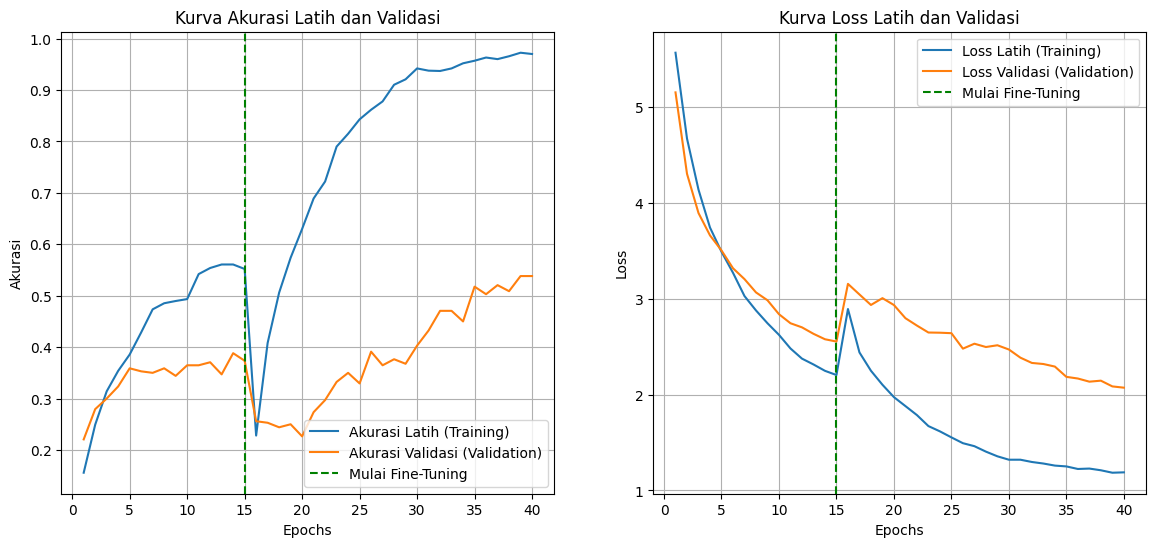

In [12]:
# ==========================================
# 5. VISUALISASI LEARNING CURVES
# ==========================================
print("Menghasilkan Learning Curves...")

# Menggabungkan data metrik dari Tahap 1 (Feature Extraction) dan Tahap 2 (Fine-Tuning)
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Menentukan titik transisi fine-tuning
initial_epochs = len(history_phase1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# 1. Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih (Training)')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Akurasi Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih (Training)')
plt.plot(epochs_range, val_loss, label='Loss Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Loss Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Menyimpan grafik ke folder reports
lc_path = os.path.join('reports', 'learning_curves_mobilenet.png')
plt.savefig(lc_path)
print(f"Learning Curves berhasil disimpan di: {lc_path}")

plt.show()
